In [35]:
%ls /content

All_Beauty_Reviews_Filtered_With_Images.jsonl  sample_data/
best_model_state.bin


In [36]:
%pip install seaborn matplotlib

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap

# Torch ML libraries
import transformers
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
import torch
from torch import nn, optim
from torch.optim import AdamW  # ✅ import from torch instead
from torch.utils.data import Dataset, DataLoader

In [38]:
%config InlineBackend.figure_format='retina'

# Graph Designs
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 12, 8

# Random seed for reproducibilty
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
import pandas as pd

data = pd.read_json(
    r"All_Beauty_Reviews_Filtered_With_Images.jsonl",
    lines=True,
    nrows=1000
)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)  # adjust width as needed
pd.set_option('display.width', 1000)
data['rating'] = data['rating'].astype(int)
data.head(12)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,4,Pretty Color,The polish was quiet thick and did not apply smoothly. I let dry overnight before adding a second coat since it was so thick.,"[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL800_.jpg', 'la...",B00R8DXL44,B00R8DXL44,AGMJ3EMDVL6OWBJF7CA5RGJLXN5A,2020-08-27 22:30:08.138,0,True
1,3,Meh,These were lightweight and soft but much too small for my liking. I would have preferred two of these together to make one loc. For that reason I will not be repurchasing.,"[{'small_image_url': 'https://m.media-amazon.com/images/I/81FN4c0VHzL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/81FN4c0VHzL._SL800_.jpg', 'large_image_url': 'https://m...",B088SZDGXG,B08BBQ29N5,AEYORY2AVPMCPDV57CE337YU5LXA,2021-10-15 05:20:59.292,0,True
2,5,Nice colors and dries fast,Haven’t worn it very long yet so can’t comment on longevity but looks great and dried pretty fast.,"[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/81H68QJM7uL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/81H68QJM7uL._SL800_.jpg', 'la...",B07H281V4V,B07H281V4V,AHW7W34BLHHC4AYM4TPMLA2SWMMA,2020-12-31 17:13:27.770,0,True
3,5,Absolutely beautiful,"These diamond are absolutely beautiful and shine so well. Not cheesy like some of the colored diamonds can, does not look like cheap plastic at all.<br />I would definitely buy again.<br />Follow ...","[{'small_image_url': 'https://m.media-amazon.com/images/I/A1u4jV10XQL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/A1u4jV10XQL._SL800_.jpg', 'large_image_url': 'https://m...",B095SC4J8T,B095SC4J8T,AH4CGRSYSW5CWLRGQYRZKNJBUPAA,2021-08-17 02:11:43.947,0,True
4,5,Doesn't Sting or Burn My Eyes!,"I am in my late 40's and started using anti-aging products a few years ago. Because I have been using products to work on wrinkles and younger looking skin regularly for the past few years, it's d...","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/41FMcmkZDLL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/41FMcmkZDLL._SL800_.jpg', 'la...",B01CO73OIQ,B01CO73OIQ,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-06-28 14:13:38.000,8,True
5,4,Best Peeling Kit I've Tried So Far,"This is the 3rd peel foot mask that I have tried. The others have been unsuccessful. Still wanting to experience the foot peel, I tried again. The first thing that makes this foot peel better than...","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51RSDWWsvhL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51RSDWWsvhL._SL800_.jpg', 'la...",B00KR4AFJU,B00KR4AFJU,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-04-11 22:28:08.000,0,False
6,4,Fun to Use!,My daughter and I discovered facial sheet masks over the summer and have become fans of them. They are easy and fun to use. This box of Anti-Aging sheet masks comes with 5 masks. Each mask is indi...,"[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51FFKVqctXL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51FFKVqctXL._SL800_.jpg', 'la...",B015ZXMSFQ,B015ZXMSFQ,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-02-14 15:48:53.000,3,False
7,4,Slight Fading of Burns So Far,"I burned my back of my hand in a couple of spots this past fall and have been using FLAWless for a short period of time to see if it helps lesson the appearance of those burns. First of all, I wou...","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/513UrgWCy4L._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/513UrgWCy4L._SL800_.jpg', 'la...",B00KXFD75M,B00KXFD75M,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-02-04 22:48:30.000,0,False
8,5,Looks Great!,"I am 

In [40]:
data.isnull().sum()

,0
rating,0
title,0
text,0
images,0
asin,0
parent_asin,0
user_id,0
timestamp,0
helpful_vote,0
verified_purchase,0


Text(0.5, 0, 'rating')

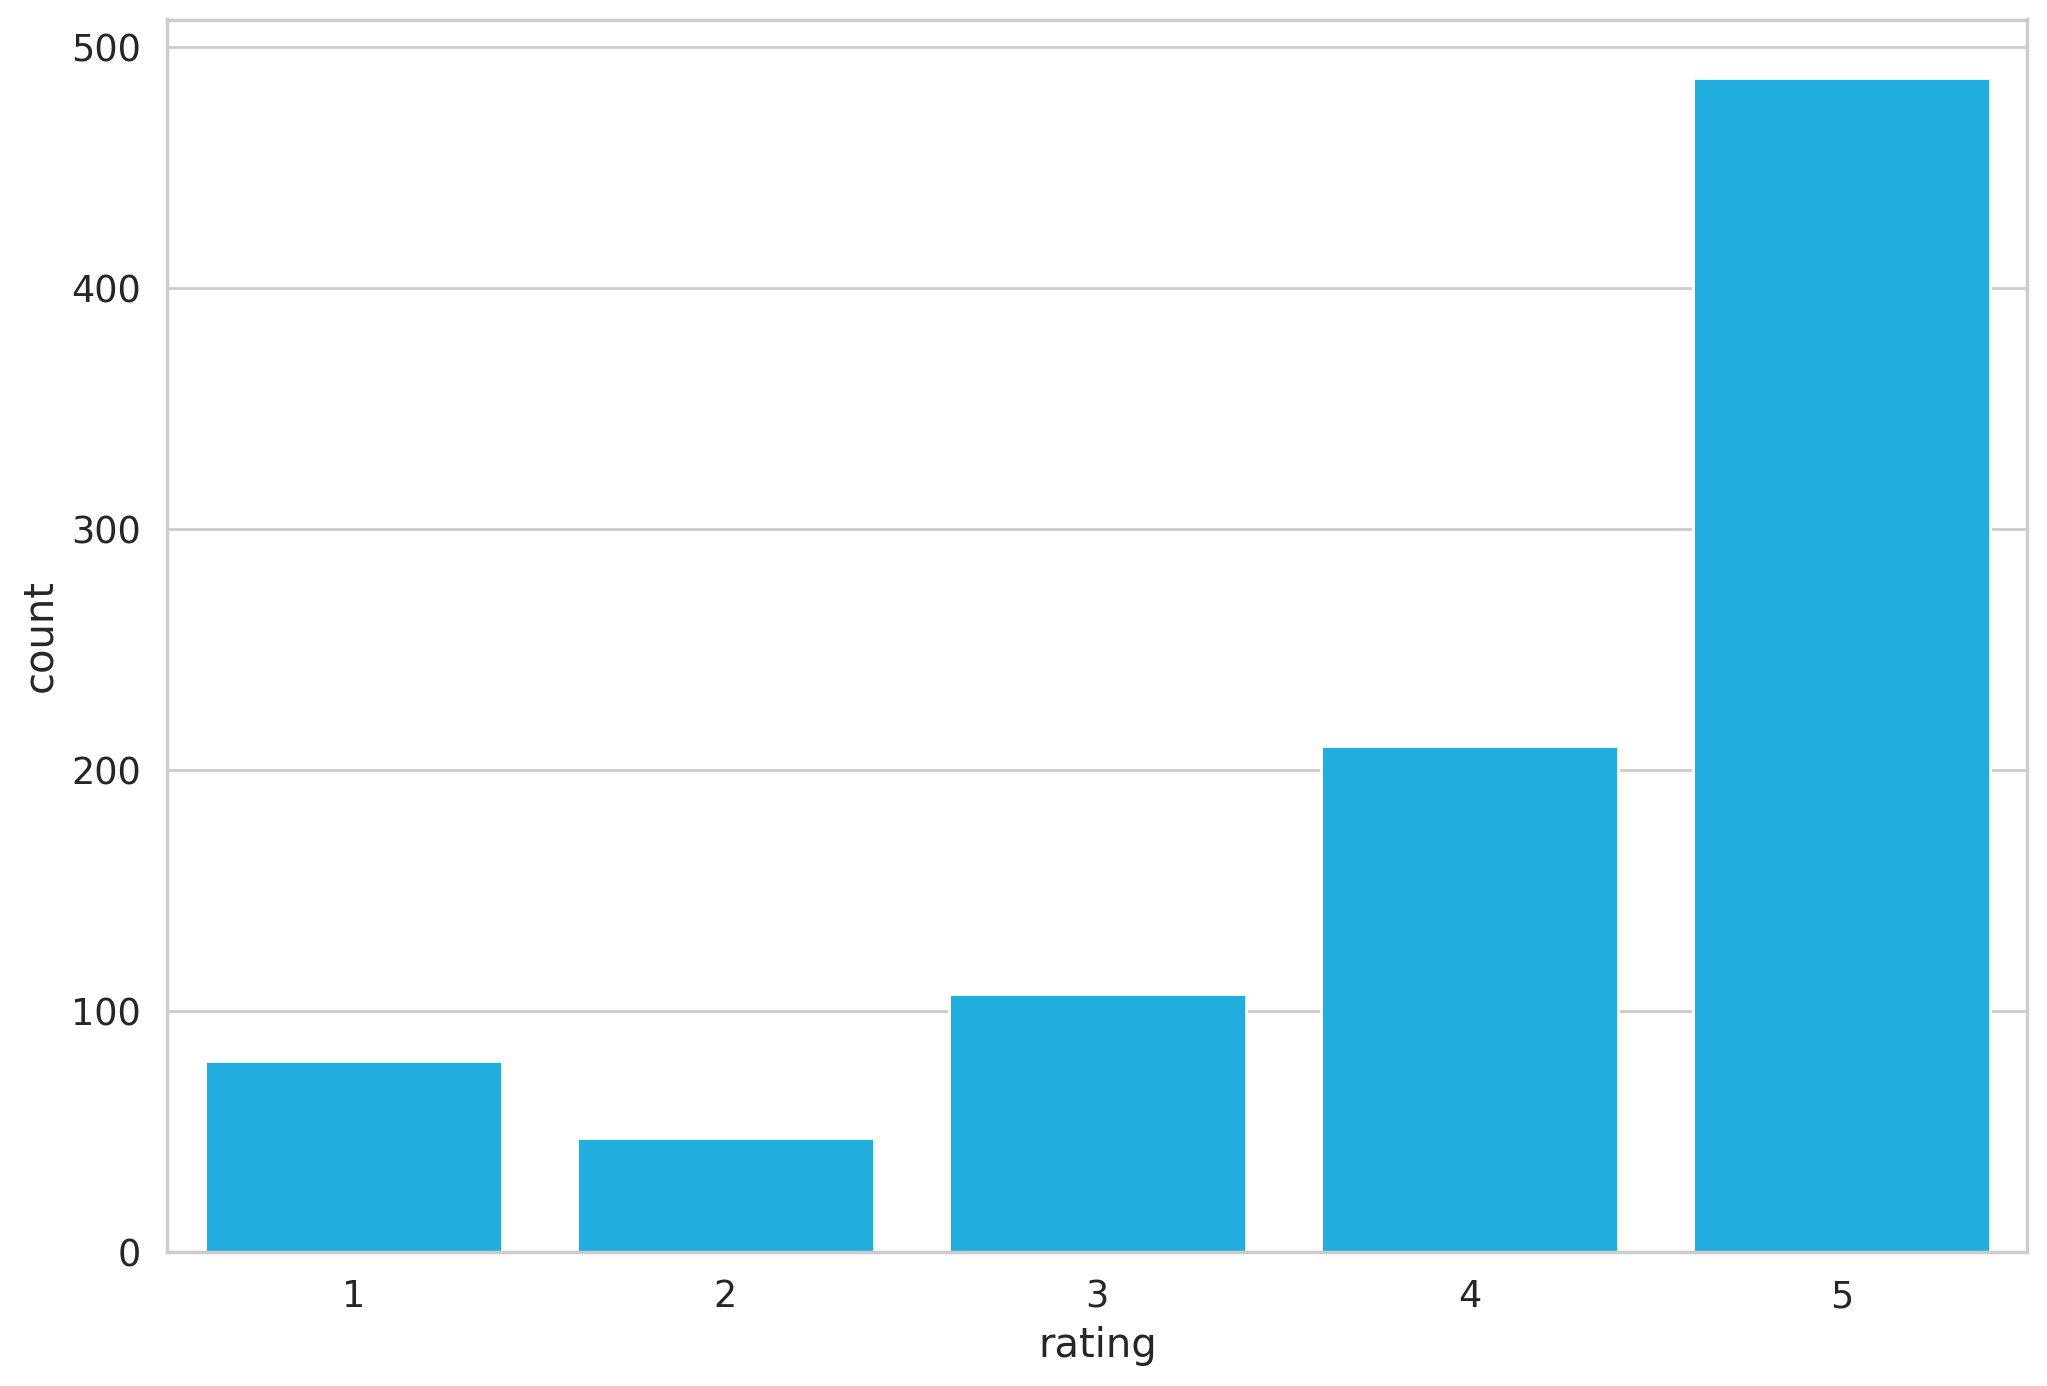

In [41]:
sns.countplot(x='rating', data=data)
plt.xlabel('rating')

In [42]:
NEGATIVE = 0
NEUTRAL  = 1
POSITIVE = 2
def to_sentiment(rating):
    rating = int(rating)
    if rating <= 2:
        return NEGATIVE
    elif rating == 3:
        return NEUTRAL
    else:
         return POSITIVE
data.insert(0, 'sentiment', data['rating'].apply(to_sentiment))

In [43]:
data.head(10)

,sentiment,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,2,4,Pretty Color,The polish was quiet thick and did not apply smoothly. I let dry overnight before adding a second coat since it was so thick.,"[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL800_.jpg', 'la...",B00R8DXL44,B00R8DXL44,AGMJ3EMDVL6OWBJF7CA5RGJLXN5A,2020-08-27 22:30:08.138,0,True
1,1,3,Meh,These were lightweight and soft but much too small for my liking. I would have preferred two of these together to make one loc. For that reason I will not be repurchasing.,"[{'small_image_url': 'https://m.media-amazon.com/images/I/81FN4c0VHzL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/81FN4c0VHzL._SL800_.jpg', 'large_image_url': 'https://m...",B088SZDGXG,B08BBQ29N5,AEYORY2AVPMCPDV57CE337YU5LXA,2021-10-15 05:20:59.292,0,True
2,2,5,Nice colors and dries fast,Haven’t worn it very long yet so can’t comment on longevity but looks great and dried pretty fast.,"[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/81H68QJM7uL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/81H68QJM7uL._SL800_.jpg', 'la...",B07H281V4V,B07H281V4V,AHW7W34BLHHC4AYM4TPMLA2SWMMA,2020-12-31 17:13:27.770,0,True
3,2,5,Absolutely beautiful,"These diamond are absolutely beautiful and shine so well. Not cheesy like some of the colored diamonds can, does not look like cheap plastic at all.<br />I would definitely buy again.<br />Follow ...","[{'small_image_url': 'https://m.media-amazon.com/images/I/A1u4jV10XQL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/A1u4jV10XQL._SL800_.jpg', 'large_image_url': 'https://m...",B095SC4J8T,B095SC4J8T,AH4CGRSYSW5CWLRGQYRZKNJBUPAA,2021-08-17 02:11:43.947,0,True
4,2,5,Doesn't Sting or Burn My Eyes!,"I am in my late 40's and started using anti-aging products a few years ago. Because I have been using products to work on wrinkles and younger looking skin regularly for the past few years, it's d...","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/41FMcmkZDLL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/41FMcmkZDLL._SL800_.jpg', 'la...",B01CO73OIQ,B01CO73OIQ,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-06-28 14:13:38.000,8,True
5,2,4,Best Peeling Kit I've Tried So Far,"This is the 3rd peel foot mask that I have tried. The others have been unsuccessful. Still wanting to experience the foot peel, I tried again. The first thing that makes this foot peel better than...","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51RSDWWsvhL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51RSDWWsvhL._SL800_.jpg', 'la...",B00KR4AFJU,B00KR4AFJU,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-04-11 22:28:08.000,0,False
6,2,4,Fun to Use!,My daughter and I discovered facial sheet masks over the summer and have become fans of them. They are easy and fun to use. This box of Anti-Aging sheet masks comes with 5 masks. Each mask is indi...,"[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51FFKVqctXL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/51FFKVqctXL._SL800_.jpg', 'la...",B015ZXMSFQ,B015ZXMSFQ,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-02-14 15:48:53.000,3,False
7,2,4,Slight Fading of Burns So Far,"I burned my back of my hand in a couple of spots this past fall and have been using FLAWless for a short period of time to see if it helps lesson the appearance of those burns. First of all, I wou...","[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/513UrgWCy4L._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/513UrgWCy4L._SL800_.jpg', 'la...",B00KXFD75M,B00KXFD75M,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2016-02-04 22:48:30.000,0,Fal

Text(0.5, 0, 'review sentiment')

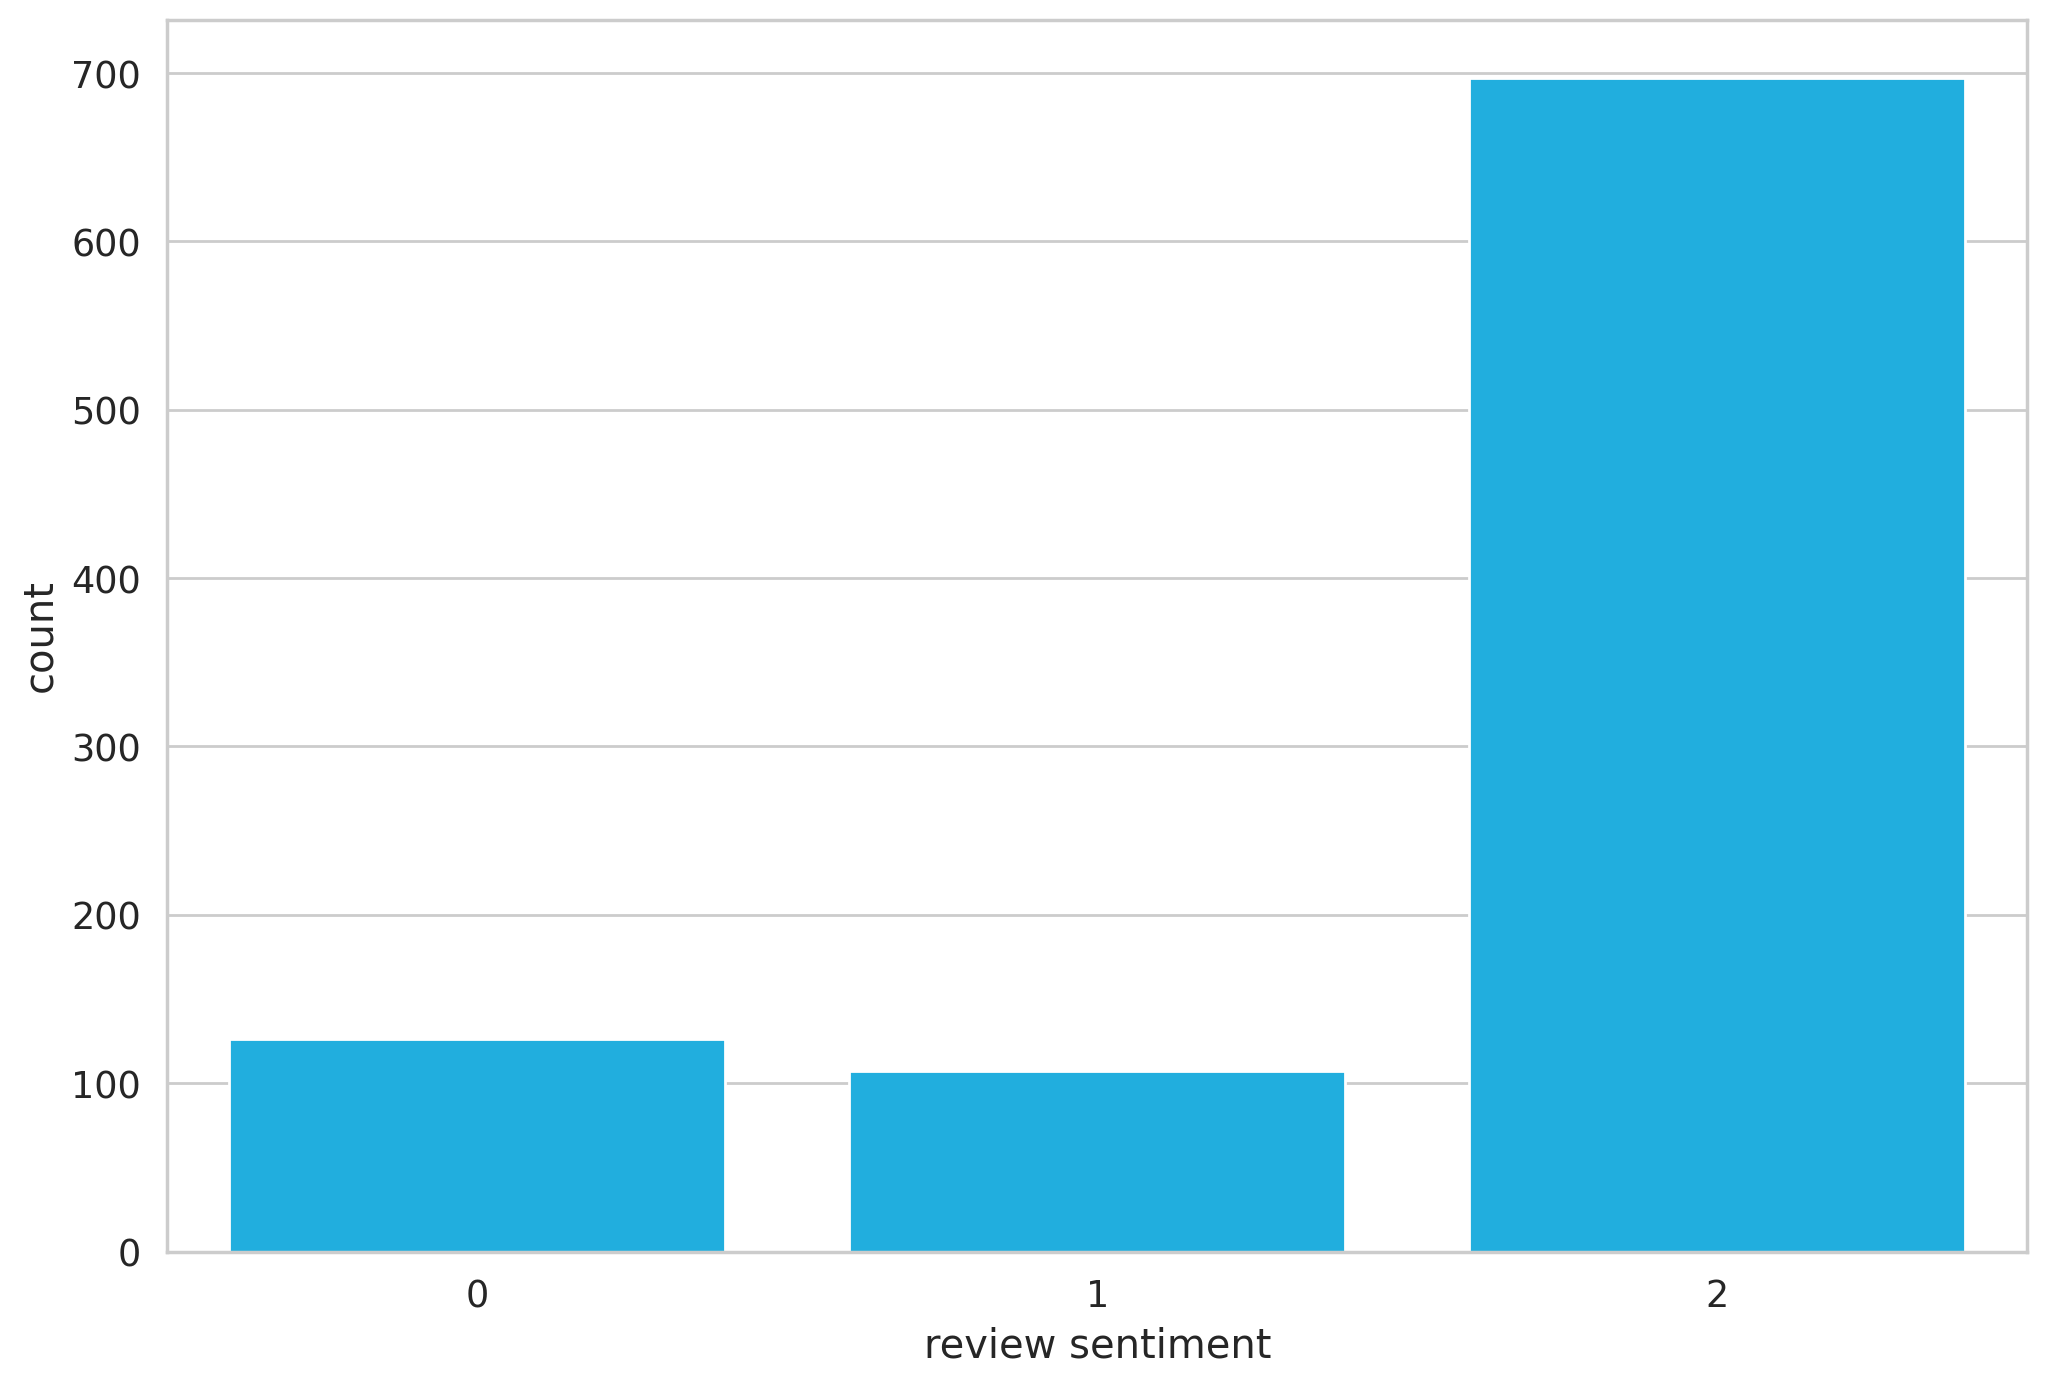

In [44]:

ax = sns.countplot(x='sentiment', data=data)
plt.xlabel('review sentiment')

In [45]:
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

In [46]:
# Some of the common BERT tokens
print(tokenizer.sep_token, tokenizer.sep_token_id) # marker for ending of a sentence
print(tokenizer.cls_token, tokenizer.cls_token_id) # start of each sentence, so BERT knows we’re doing classification
print(tokenizer.pad_token, tokenizer.pad_token_id) # special token for padding
print(tokenizer.unk_token, tokenizer.unk_token_id) # tokens not found in training set 

[SEP] 102
[CLS] 101
[PAD] 0
[UNK] 100


In [47]:
token_lens = []

for text in data.text:
    token = tokenizer.encode(text,max_length=512)
    token_lens.append(len(token))

print(token_lens)

[28, 41, 25, 56, 261, 417, 395, 203, 299, 114, 65, 12, 224, 117, 163, 167, 149, 202, 249, 285, 164, 352, 195, 273, 376, 273, 335, 335, 53, 308, 107, 174, 206, 228, 244, 135, 170, 120, 179, 183, 102, 137, 229, 89, 341, 119, 206, 115, 110, 122, 130, 272, 91, 119, 119, 151, 161, 201, 280, 374, 236, 224, 207, 127, 152, 209, 210, 227, 443, 133, 137, 330, 119, 244, 105, 244, 121, 280, 93, 97, 49, 236, 171, 512, 108, 272, 324, 512, 28, 194, 107, 11, 140, 120, 100, 218, 100, 197, 189, 183, 126, 118, 89, 357, 228, 146, 199, 195, 158, 103, 131, 256, 107, 184, 91, 79, 32, 68, 71, 111, 78, 194, 512, 287, 387, 395, 512, 144, 20, 36, 45, 46, 33, 29, 37, 31, 40, 14, 510, 149, 102, 339, 340, 460, 328, 432, 135, 286, 228, 512, 495, 448, 368, 343, 344, 512, 512, 220, 512, 512, 131, 486, 167, 61, 40, 41, 512, 171, 57, 71, 108, 68, 67, 112, 70, 84, 89, 69, 77, 114, 96, 298, 244, 263, 106, 185, 76, 73, 46, 38, 61, 92, 60, 58, 135, 103, 46, 101, 49, 64, 96, 122, 90, 237, 117, 94, 141, 95, 46, 51, 70, 115, 2

In [48]:
print(type(token_lens))
print(type(token_lens[0]))
token_lens = np.array(token_lens)
print(type(token_lens))
print(type(token_lens[0]))

<class 'list'>
<class 'int'>
<class 'numpy.ndarray'>
<class 'numpy.int64'>


Text(0.5, 0, 'Token Count')

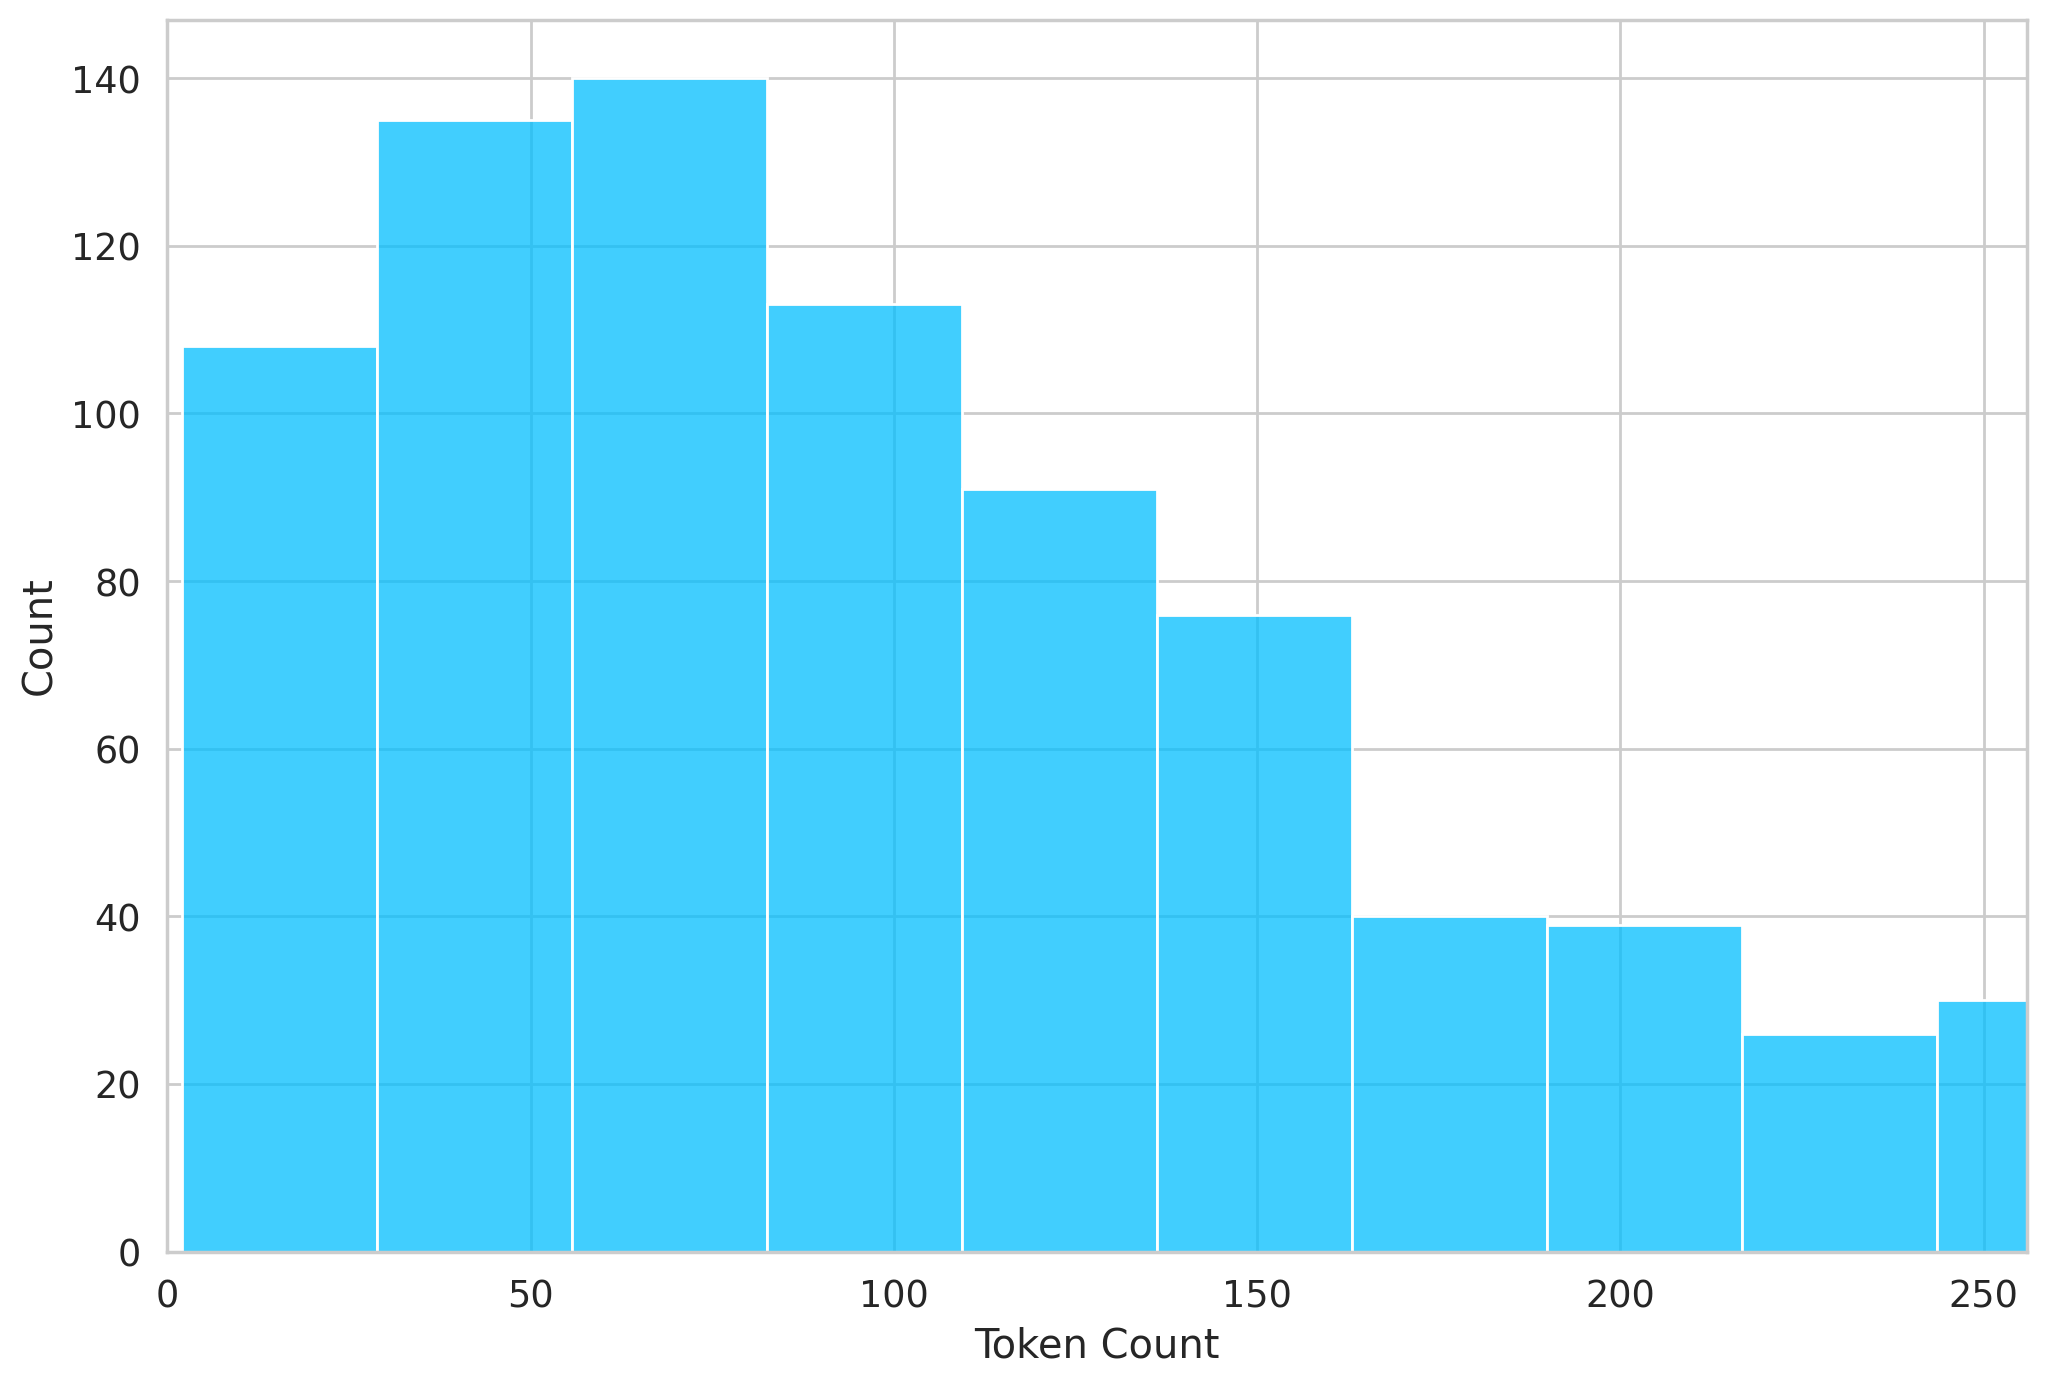

In [49]:
sns.histplot(token_lens)
plt.xlim([0, 256])
plt.xlabel('Token Count')

In [50]:
MAX_LEN = 300

In [51]:
class ABReviewDataset(Dataset):

    def __init__(self,reviews,targets,tokenizer,max_len):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)
    
    def __getitem__(self,item):
        review = str(self.reviews[item])
        target = self.targets[item]

        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }

In [52]:
data_train, data_test = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED)
data_val, data_test = train_test_split(data_test, test_size=0.5, random_state=RANDOM_SEED)
print(data_train.shape, data_val.shape, data_test.shape)

(744, 11) (93, 11) (93, 11)


In [53]:
def create_data_loader(data,tokenizer,max_len,batch_size):
    ds = ABReviewDataset(
        reviews=data.text.to_numpy(),
        targets=data.sentiment.to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        num_workers=0
    )

In [54]:
BATCH_SIZE = 16
train_data_loader = create_data_loader(data_train,tokenizer,MAX_LEN,BATCH_SIZE)
val_data_loader = create_data_loader(data_val,tokenizer,MAX_LEN,BATCH_SIZE)
test_data_loader = create_data_loader(data_test,tokenizer,MAX_LEN,BATCH_SIZE)

In [55]:
data = next(iter(train_data_loader))
print(data.keys())

print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])
torch.Size([16, 300])
torch.Size([16, 300])
torch.Size([16])


In [56]:
bert_model = BertModel.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [57]:
class SentimentClassifier(nn.Module):

    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)          # ✅ no trailing comma
        self.drop = nn.Dropout(p=0.5)  # ✅ no trailing comma
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = output.pooler_output
        output = self.drop(pooled_output)
        return self.out(output)

In [58]:
NO_OF_CLASSES = 3
model = SentimentClassifier(NO_OF_CLASSES)
model = model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [59]:
print(bert_model.config.hidden_size)

768


In [60]:
EPOCHS = 4
optimizer = AdamW(model.parameters(),lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps = 0,
    num_training_steps = total_steps
)    

class_weights = torch.tensor([5.0, 5.0, 1.0]).to(device)  # adjust based on counts
loss_fn = nn.CrossEntropyLoss(weight=class_weights).to(device)


In [61]:
#CHECKPOINT FOR SELF# CODE UPTO THIS POINT CAN BE TRUSTED

In [62]:
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)

        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        # ✅ These 3 lines were missing entirely
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()       # ✅ also missing

    return correct_predictions.double() / n_examples, np.mean(losses)

In [63]:
def eval_model(model,data_loader,loss_fn,device,n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device) 

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)
            
            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())
    return correct_predictions.double() / n_examples, np.mean(losses)

In [64]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch +1}/{EPOCHS}")
    print('-'*10)

    train_acc,train_loss = train_epoch(
        model,
        train_data_loader,
        loss_fn,
        optimizer,
        device,
        scheduler,
        len(data_train)
    )
    print(f"Train loss {train_loss} accuracy {train_acc}")

    val_acc, val_loss = eval_model(
        model,
        val_data_loader,
        loss_fn,
        device,
        len(data_val)
    )
    print(f"Val   loss {val_loss} accuracy {val_acc}")
    print()
        
    history['train_acc'].append(train_acc.cpu())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.cpu())
    history['val_loss'].append(val_loss)
        
    # If we beat prev performance
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

Epoch 1/4
----------
Train loss 1.073105459517621 accuracy 0.4301075268817205
Val   loss 0.876530110836029 accuracy 0.6344086021505377

Epoch 2/4
----------
Val   loss 0.5762414038181305 accuracy 0.8387096774193549

Epoch 4/4
----------
Train loss 0.5197860142017933 accuracy 0.8467741935483871
Val   loss 0.5580827593803406 accuracy 0.870967741935484

CPU times: user 3min, sys: 1.22 s, total: 3min 2s
Wall time: 3min 15s


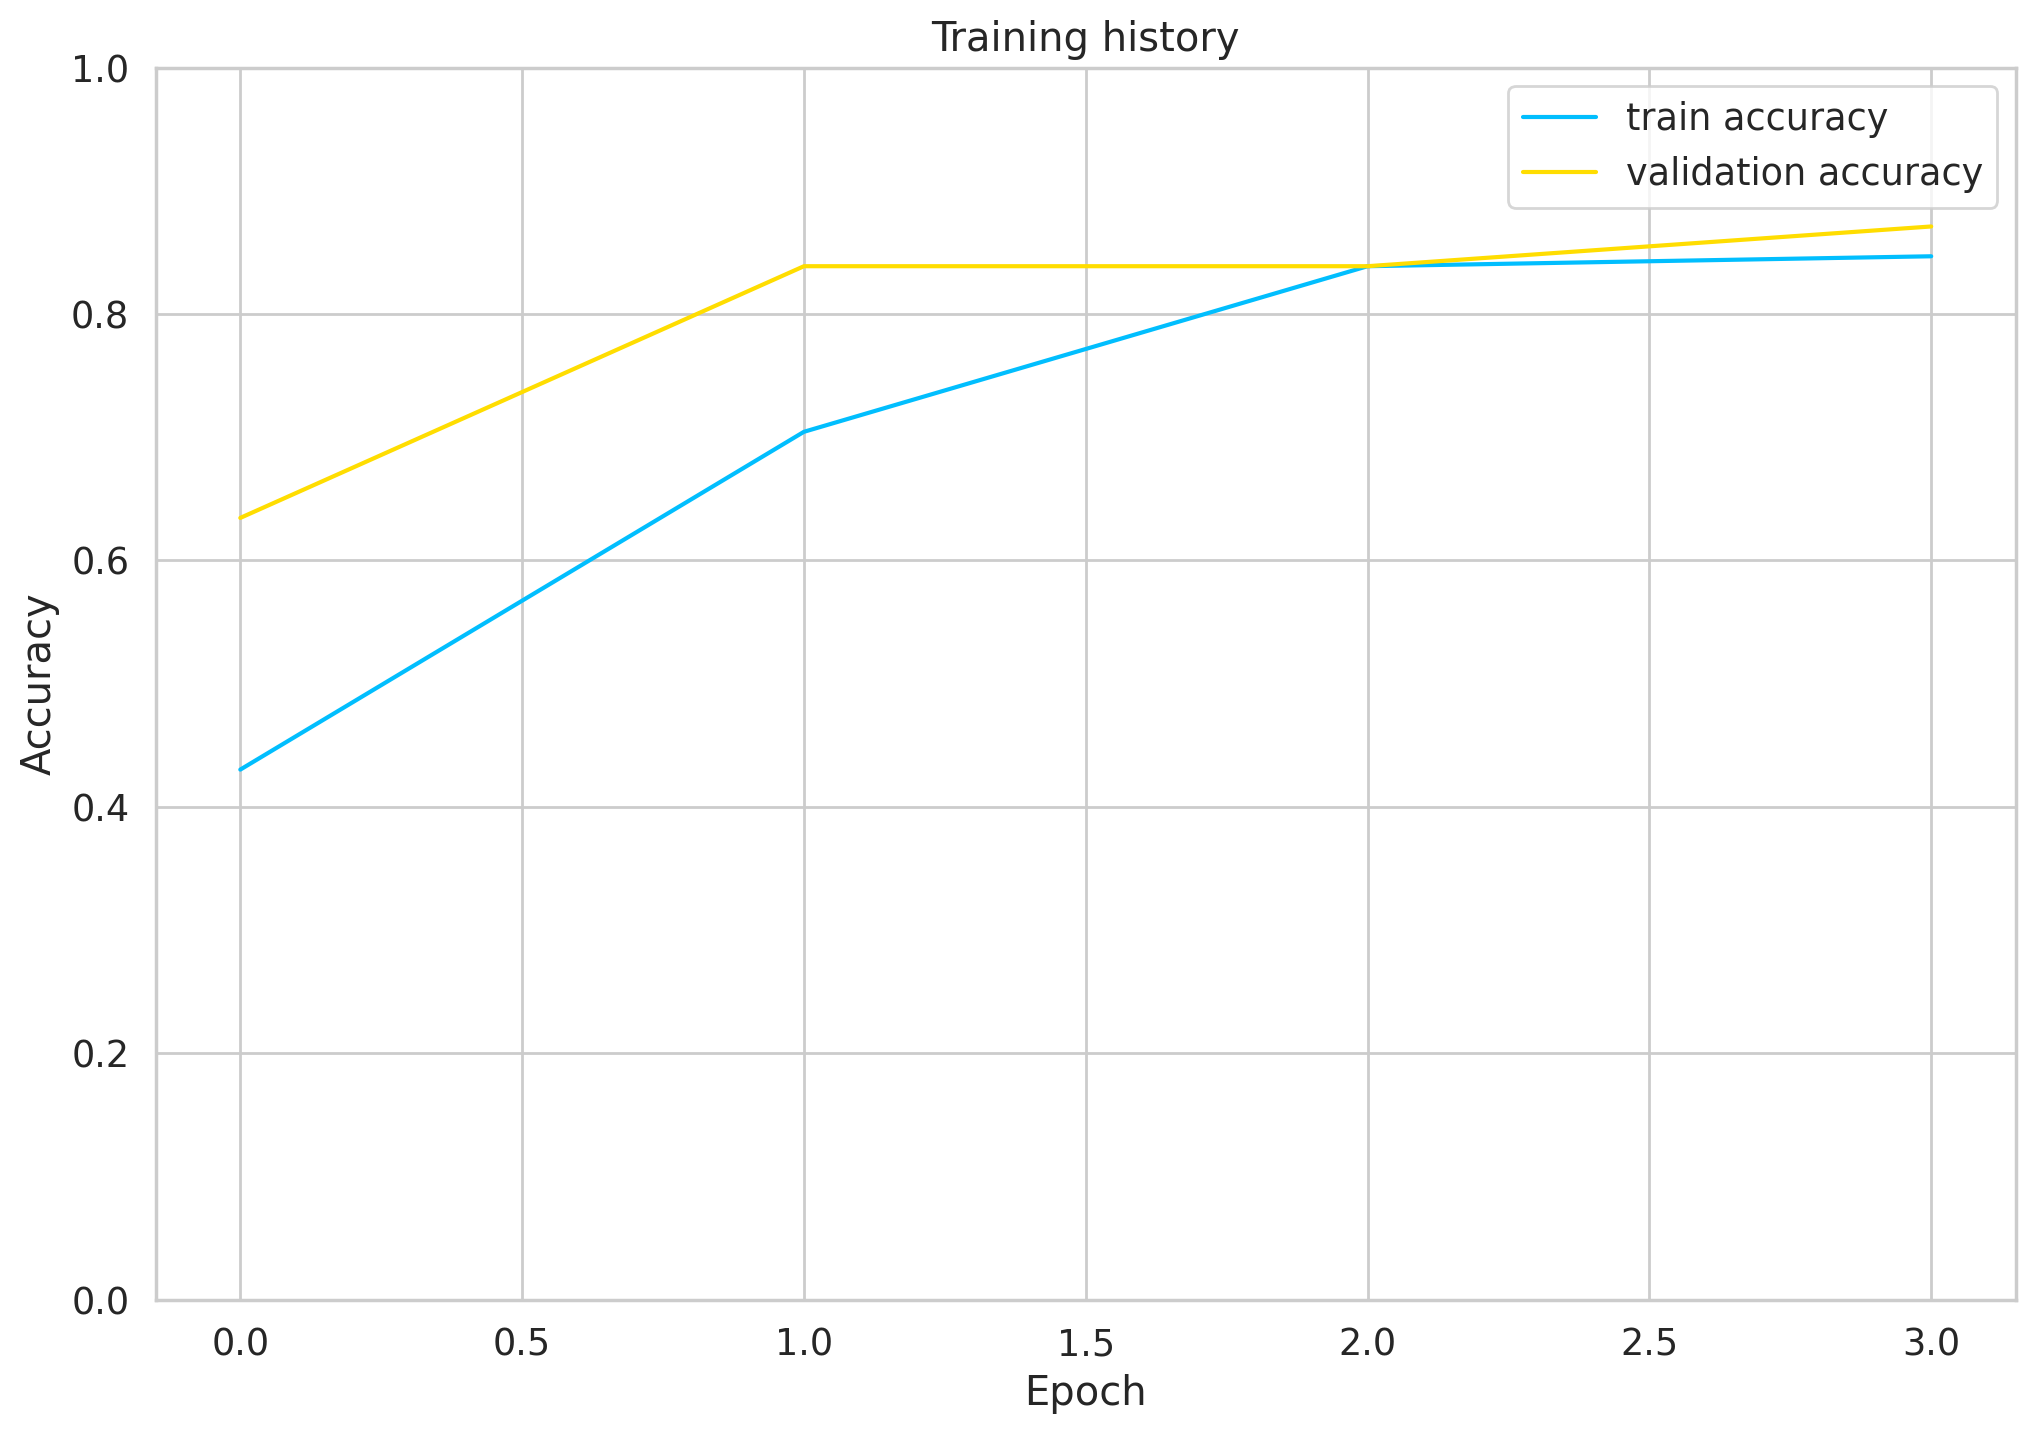

In [65]:
plt.plot(history["train_acc"],label="train accuracy")
plt.plot(history["val_acc"],label="validation accuracy")

# Graph chars
plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);   

In [66]:
test_acc, _ = eval_model(
    model,
    test_data_loader,
    loss_fn,
    device,
    len(data_test)
)

test_acc.item()

0.8279569892473119

In [67]:
def get_predictions(model,data_loader):
    model = model.eval()

    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            _,preds = torch.max(outputs,dim=1)

            review_texts.extend(texts)
            predictions.extend(preds)
            prediction_probs.extend(outputs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    prediction_probs = torch.stack(prediction_probs).cpu()
    real_values = torch.stack(real_values).cpu()

    return review_texts,predictions,prediction_probs,real_values

In [68]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    model,
    test_data_loader
)

In [69]:
print(classification_report(y_test,y_pred,target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.73      0.62      0.67        13
     neutral       0.43      0.60      0.50        10
    positive       0.93      0.90      0.91        70

    accuracy                           0.83        93
   macro avg       0.69      0.71      0.69        93
weighted avg       0.85      0.83      0.83        93



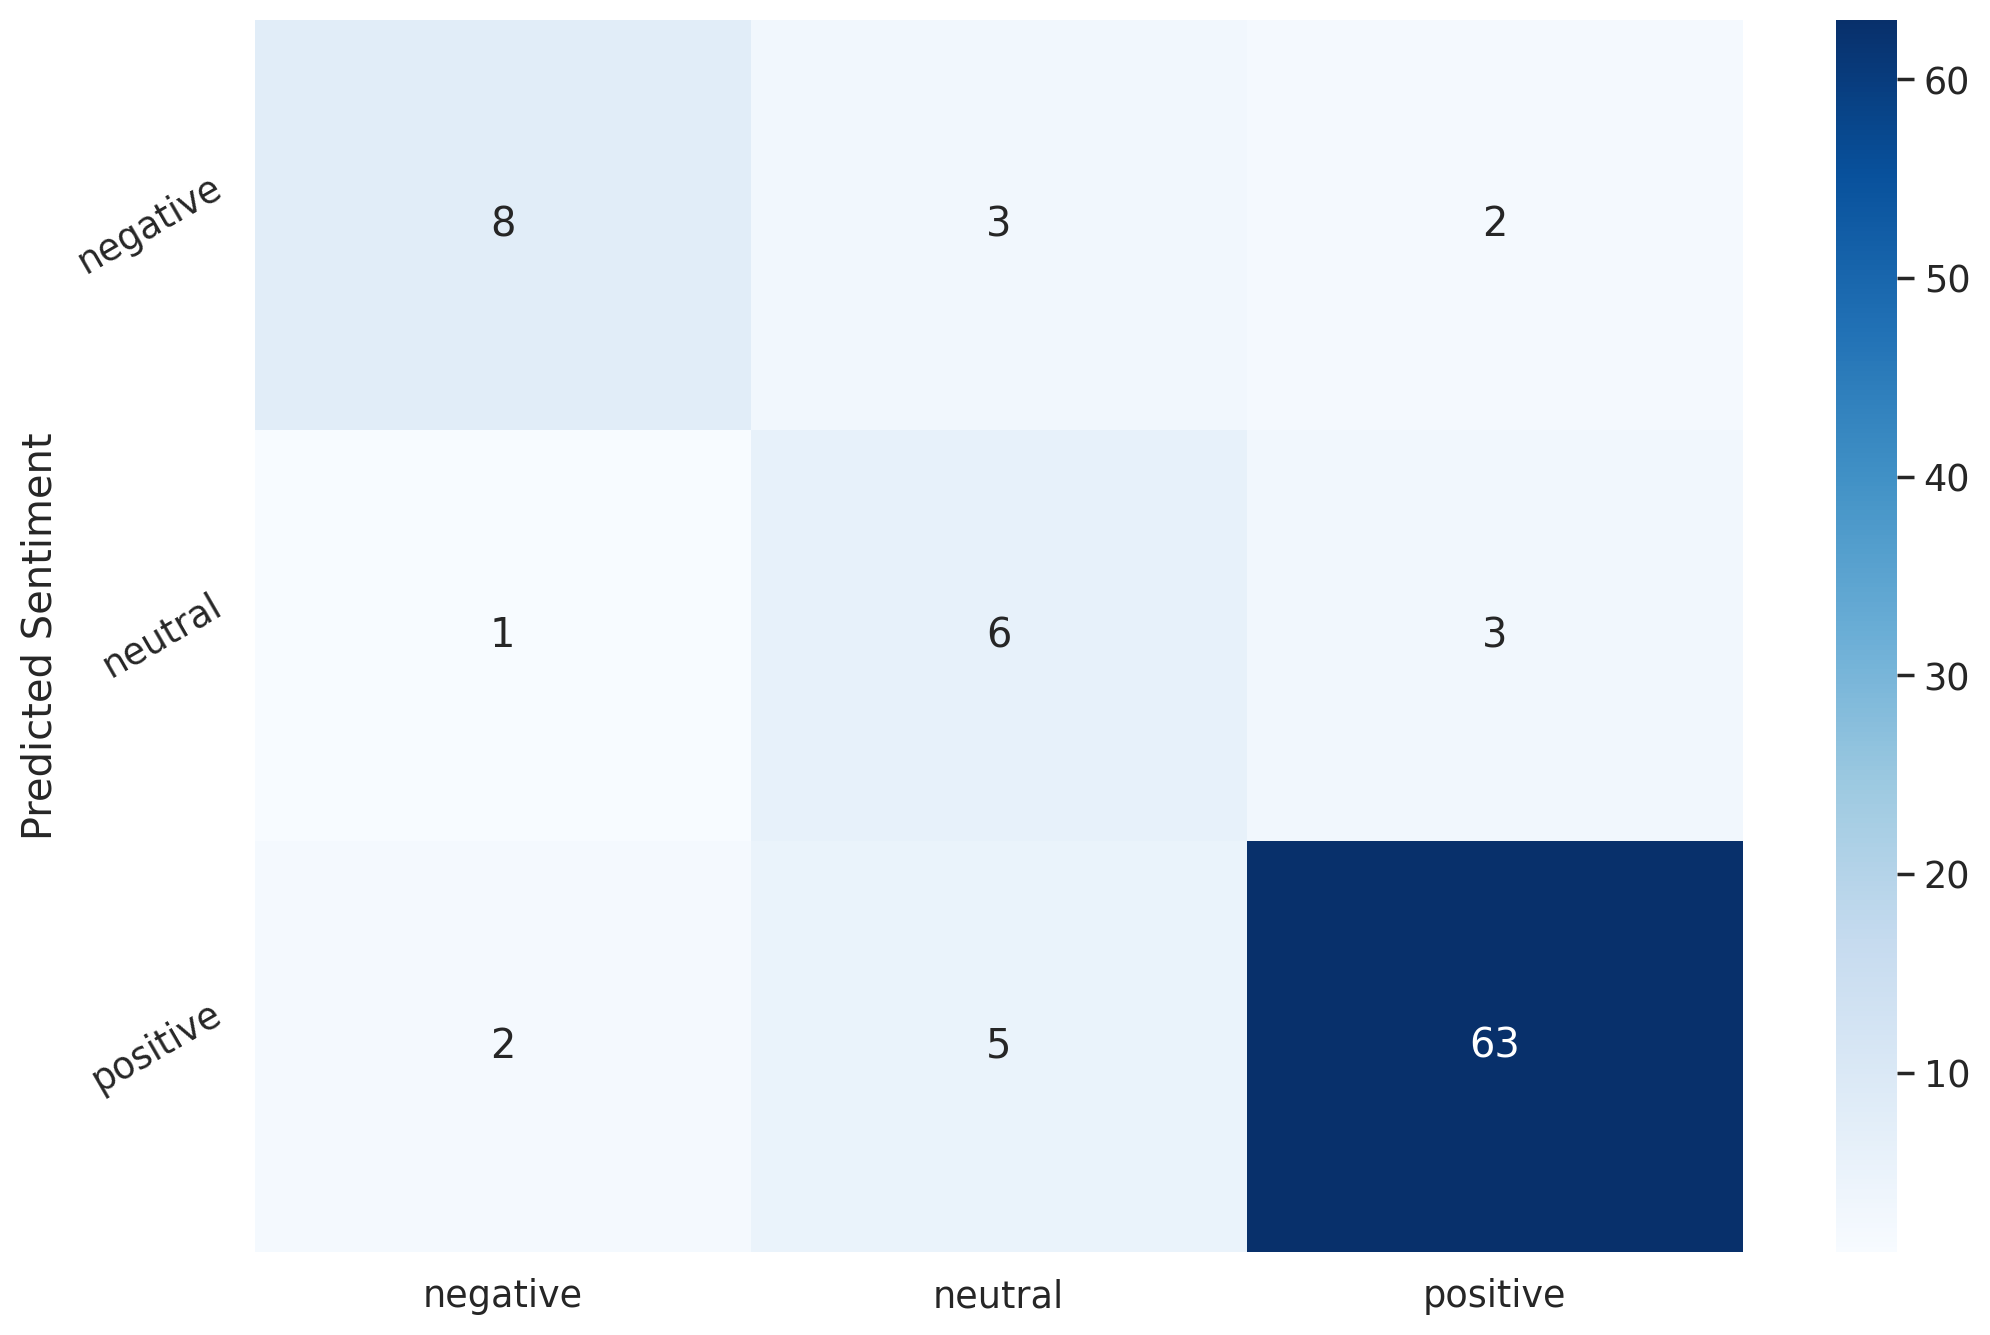

In [70]:
def show_confusion_matrix(confusion_matrix):
    hmap = sns.heatmap(confusion_matrix,annot=True,fmt="d",cmap="Blues")
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(),rotation=0,ha="right")
    hmap.yaxis.set_ticklabels(hmap.xaxis.get_ticklabels(),rotation=30,ha="right")
    plt.ylabel("True Sentiment")
    plt.ylabel("Predicted Sentiment")

cm = confusion_matrix(y_test,y_pred)
data_cm = pd.DataFrame(cm,index=['negative', 'neutral', 'positive'],columns=['negative', 'neutral', 'positive'])
show_confusion_matrix(data_cm)

In [86]:
raw_text = "The website printed on the box does not exist. No other website seems to exist to provide information.  Product came with the box open, no type of seal. Label is peeling off. Extremely suspicious, huge red flag."

In [87]:
encoded_review = tokenizer(
    raw_text,
    max_length=MAX_LEN,
    add_special_tokens=True,
    return_token_type_ids=False,
    padding='max_length',        # replaces pad_to_max_length
    truncation=True,             # required when specifying max_length
    return_attention_mask=True,
    return_tensors='pt'
)

In [88]:
input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

output = model(input_ids,attention_mask)
_,prediction = torch.max(output,dim=1)

class_names = ['Negative','Neutral','Positive']

print(f'Review Text:{raw_text}')
print(f'Sentiment:{prediction}')

Review Text:The website printed on the box does not exist. No other website seems to exist to provide information.  Product came with the box open, no type of seal. Label is peeling off. Extremely suspicious, huge red flag.
Sentiment:tensor([0], device='cuda:0')


1. Train loss drops, val loss follows == Model is learning and generalizing
2. Train loss drops, val loss rises   == Overfitting — add dropout or reduce epochs.
3. Both losses barely move == Frozen weights, wrong LR, or bad data
4. Val loss identical every epoch == Bug in the code